## **출발셀이 랜덤인 Grid World 환경**

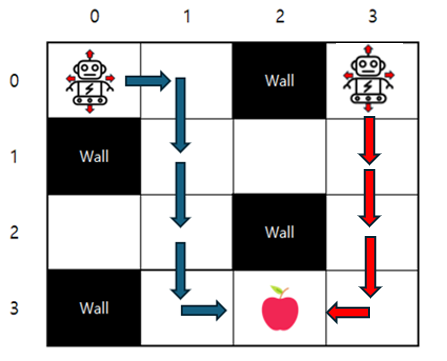

[환경 설정]

In [ ]:
## 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# 환경 설정
그리드_수=[4, 4]
목표_셀=(3, 2)
차단_셀=[(2, 2), (3,0), (1,0), (0,2)]

행동_이름=['up', 'down', 'left', 'right']
n_actions=4  # 행동의 수

가능한_출발_셀 = []
for r in range(그리드_수[0]):
    for c in range(그리드_수[1]):
        현재_셀 = (r, c)
        if (현재_셀 not in 차단_셀) and (현재_셀 != 목표_셀):
            가능한_출발_셀.append([r, c])

[상태 변화와 보상 함수 설정]

In [ ]:

def state_move(state, action):
    x, y = state
    if action == 0:    # up
        next = (max(x - 1, 0), y)
    elif action == 1:  # down
        next = (min(x + 1, 3), y)
    elif action == 2:  # left
        next = (x, max(y - 1, 0))
    elif action == 3:  # right
        next = (x, min(y + 1, 3))

    if next in 차단_셀:
        next = state
    return next

def reward(state):
    return 1 if state == 목표_셀 else -0.1

[에피소드별 출발 셀을 랜덤하게 설정 후 학습 실행]

In [ ]:
# 하이퍼 파라미터 설정
gamma=0.9       # 할인율
n_episodes=1000  # 에피소드 수

e=1		  # 초기 탐험 비율
e_decay=0.99	  # 탐험 비율 감소율

#np.random.seed(42); random.seed(42)   # 출발셀이 랜덤하게 달라질 수 있도록 시드 고정을 하지 않습니다.

# Q-테이블 초기화
Q=np.random.rand(4, 4, 4)

# 학습 루프
for ep in range(n_episodes):
    출발_셀 = random.choice(가능한_출발_셀)  # 에피소드마다 출발 셀 랜덤 선택
    상태=출발_셀
    총_보상=0
    종료=False
    step=0

    while 종료==False:
        step+=1
        if random.uniform(0, 1) < e:
            행동=random.randint(0, 3)               # 탐험
        else:
            행동=np.argmax(Q[상태[0], 상태[1], :])  # 활용

        다음_상태=state_move(상태, 행동)
        보상=reward(다음_상태)
        총_보상 += 보상
        종료=(다음_상태 == 목표_셀)


        # 벨만 방정식으로 Q값 업데이트
        Q[상태[0], 상태[1], 행동]=보상 + gamma*np.max(Q[다음_상태[0], 다음_상태[1], :])*(종료==False)

        상태=다음_상태

    e=e*e_decay  # 탐험 비율 감소
    print(
        f"에피소드={ep+1:4} | "
        f"출발 셀={출발_셀} | "
        f"탐험비율={e:.5f}  |"
        f"목표 도달 스텝 수={step:2}  |"
        f"총_보상={총_보상:.2f} | " )

print()
print("학습 완료된 Q-테이블")
print(Q)

에피소드=   1 | 출발 셀=[3, 3] | 탐험비율=0.99000  |목표 도달 스텝 수= 1  |총_보상=1.00 | 
에피소드=   2 | 출발 셀=[2, 3] | 탐험비율=0.98010  |목표 도달 스텝 수=59  |총_보상=-4.80 | 
에피소드=   3 | 출발 셀=[2, 0] | 탐험비율=0.97030  |목표 도달 스텝 수=18  |총_보상=-0.70 | 
에피소드=   4 | 출발 셀=[2, 1] | 탐험비율=0.96060  |목표 도달 스텝 수=13  |총_보상=-0.20 | 
에피소드=   5 | 출발 셀=[3, 3] | 탐험비율=0.95099  |목표 도달 스텝 수= 2  |총_보상=0.90 | 
에피소드=   6 | 출발 셀=[0, 1] | 탐험비율=0.94148  |목표 도달 스텝 수=204  |총_보상=-19.30 | 
에피소드=   7 | 출발 셀=[1, 3] | 탐험비율=0.93207  |목표 도달 스텝 수=40  |총_보상=-2.90 | 
에피소드=   8 | 출발 셀=[0, 0] | 탐험비율=0.92274  |목표 도달 스텝 수=55  |총_보상=-4.40 | 
에피소드=   9 | 출발 셀=[1, 2] | 탐험비율=0.91352  |목표 도달 스텝 수=67  |총_보상=-5.60 | 
에피소드=  10 | 출발 셀=[1, 2] | 탐험비율=0.90438  |목표 도달 스텝 수= 6  |총_보상=0.50 | 
에피소드=  11 | 출발 셀=[0, 3] | 탐험비율=0.89534  |목표 도달 스텝 수=14  |총_보상=-0.30 | 
에피소드=  12 | 출발 셀=[1, 2] | 탐험비율=0.88638  |목표 도달 스텝 수=25  |총_보상=-1.40 | 
에피소드=  13 | 출발 셀=[1, 3] | 탐험비율=0.87752  |목표 도달 스텝 수=79  |총_보상=-6.80 | 
에피소드=  14 | 출발 셀=[2, 1] | 탐험비율=0.86875  |목표 도달 스텝 수=12  |총_보상=-0.10 | 
에피소드=  

[성능 테스트]

In [ ]:
출발_셀 = random.choice(가능한_출발_셀)  # 랜덤 출발 셀 지정
상태=출발_셀
print("출발 셀=", 출발_셀)
종료=False
while 종료==False:
        행동=np.argmax(Q[상태[0], 상태[1], ])
        다음_상태=state_move(상태, 행동)
        종료=(다음_상태==목표_셀)
        상태=다음_상태
        print(상태, end="-> ")
print("목표 도달")

출발 셀= [1, 1]
(2, 1)-> (3, 1)-> (3, 2)-> 목표 도달


경로가 제대로 되었는지 확인해 보세요.

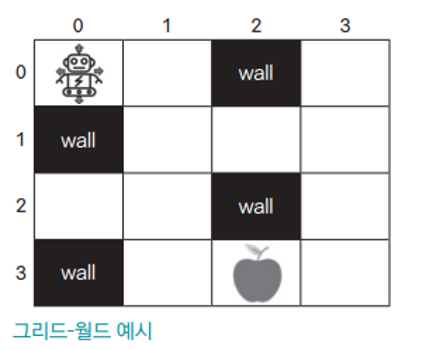